# Coreference Chain Exploration — LitBank

**Dataset:** [`coref-data/litbank_raw`](https://huggingface.co/datasets/coref-data/litbank_raw) (CC-BY-4.0)

LitBank is a coreference resolution corpus of 100 English literary works annotated with entity mentions and coreference chains. Each document comes pre-tokenized and contains:

- `sentences` — tokenized sentences as `List[List[str]]`
- `coref_chains` — clusters of mentions, each mention as `[sentence_id, start_token, end_token]` (0-based, inclusive)
- `meta_info` — author, title, Gutenberg ID

> **Note:** `tner/ontonotes5` only contains NER labels. This dataset is the appropriate free alternative for coreference chain work.

## 1. Imports

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from IPython.display import HTML, display
import random
import textwrap

/opt/anaconda3/envs/comp_disc_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the Dataset

In [3]:
# LitBank has 10 cross-validation splits (split_0 through split_9)
# We use split_0 which contains ~90 training + ~10 test documents
dataset = load_dataset("coref-data/litbank_raw", "split_0")
print(dataset)
print(f"\nTrain docs : {len(dataset['train'])}")
print(f"Test docs  : {len(dataset['test'])}")

DatasetDict({
    train: Dataset({
        features: ['doc_name', 'meta_info', 'sentences', 'coref_chains', 'entities', 'events', 'original_text', 'quotes'],
        num_rows: 80
    })
    validation: Dataset({
        features: ['doc_name', 'meta_info', 'sentences', 'coref_chains', 'entities', 'events', 'original_text', 'quotes'],
        num_rows: 10
    })
    test: Dataset({
        features: ['doc_name', 'meta_info', 'sentences', 'coref_chains', 'entities', 'events', 'original_text', 'quotes'],
        num_rows: 10
    })
})

Train docs : 80
Test docs  : 10


## 3. Inspect a Single Document

In [4]:
doc = dataset["train"][0]

meta   = doc["meta_info"]
sents  = doc["sentences"]
chains = doc["coref_chains"]

print(f"Title  : {meta['title']}")
print(f"Author : {meta['author']}")
print(f"Date   : {meta['date']}")
print(f"\nNumber of sentences   : {len(sents)}")
print(f"Number of coref chains: {len(chains)}")
print(f"\n--- First 3 sentences ---")
for i, sent in enumerate(sents[:3]):
    print(f"  [{i}] {' '.join(sent)}")

Title  : Moby Dick; Or, The Whale
Author : Melville, Herman
Date   : 1851

Number of sentences   : 94
Number of coref chains: 175

--- First 3 sentences ---
  [0] CHAPTER 1 Loomings Call me Ishmael .
  [1] Some years ago -- never mind how long precisely -- having little or no money in my purse , and nothing particular to interest me on shore , I thought I would sail about a little and see the watery part of the world .
  [2] It is a way I have of driving off the spleen and regulating the circulation .


## 4. Decode a Coreference Chain

Each chain is a list of mentions. Each mention is `[sentence_id, start_token, end_token]`.

In [5]:
def resolve_mention(sentences, mention):
    """Return the surface string for a mention [sent_id, start, end]."""
    sent_id, start, end = mention
    return " ".join(sentences[sent_id][start : end + 1])


def print_chain(sentences, chain, chain_idx):
    print(f"Chain #{chain_idx}  ({len(chain)} mentions)")
    for mention in chain:
        sent_id, start, end = mention
        surface = resolve_mention(sentences, mention)
        context = " ".join(sentences[sent_id])
        print(f"  sent={sent_id:3d} tok=[{start},{end}]  '{surface}'")
        print(f"         context: ...{context[:80]}...")
    print()


# Print the 3 longest chains in this document
sorted_chains = sorted(enumerate(chains), key=lambda x: len(x[1]), reverse=True)
for chain_idx, chain in sorted_chains[:3]:
    print_chain(sents, chain, chain_idx)

Chain #0  (65 mentions)
  sent=  0 tok=[4,4]  'me'
         context: ...CHAPTER 1 Loomings Call me Ishmael ....
  sent=  0 tok=[5,5]  'Ishmael'
         context: ...CHAPTER 1 Loomings Call me Ishmael ....
  sent=  1 tok=[16,16]  'my'
         context: ...Some years ago -- never mind how long precisely -- having little or no money in ...
  sent=  1 tok=[24,24]  'me'
         context: ...Some years ago -- never mind how long precisely -- having little or no money in ...
  sent=  1 tok=[28,28]  'I'
         context: ...Some years ago -- never mind how long precisely -- having little or no money in ...
  sent=  1 tok=[30,30]  'I'
         context: ...Some years ago -- never mind how long precisely -- having little or no money in ...
  sent=  2 tok=[4,4]  'I'
         context: ...It is a way I have of driving off the spleen and regulating the circulation ....
  sent=  3 tok=[1,1]  'I'
         context: ...Whenever I find myself growing grim about the mouth ; whenever it is a damp , dr...
  

## 5. Visualise Mention Positions Across the Document

Each row = one coreference chain. Each dot = one mention, positioned by sentence index.

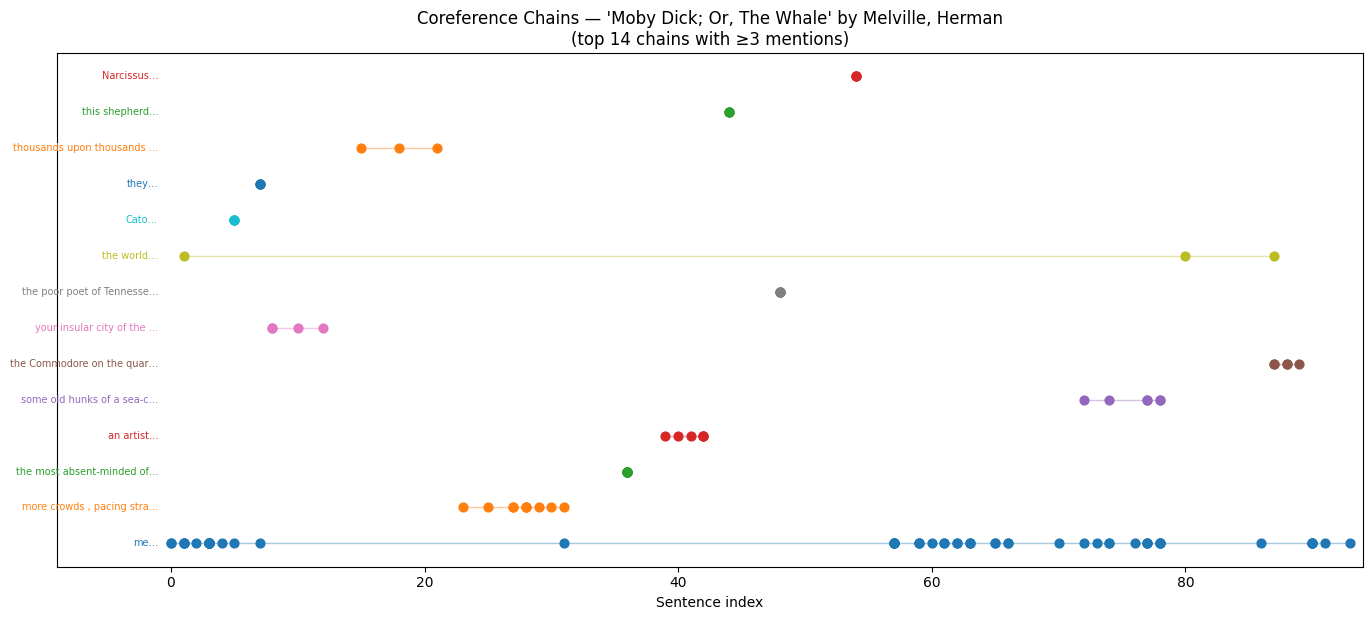

In [6]:
# Show only chains with ≥ 3 mentions to keep the plot readable
long_chains = [(i, c) for i, c in enumerate(chains) if len(c) >= 3]
long_chains_sorted = sorted(long_chains, key=lambda x: len(x[1]), reverse=True)[:20]

palette = list(mcolors.TABLEAU_COLORS.values())

fig, ax = plt.subplots(figsize=(14, max(4, len(long_chains_sorted) * 0.45)))

for row_idx, (chain_idx, chain) in enumerate(long_chains_sorted):
    color = palette[row_idx % len(palette)]
    sent_positions = [m[0] for m in chain]
    label = resolve_mention(sents, chain[0])[:25]

    # Draw a line connecting the mentions
    ax.plot(sent_positions, [row_idx] * len(sent_positions),
            "-", color=color, alpha=0.4, linewidth=1)
    ax.scatter(sent_positions, [row_idx] * len(sent_positions),
               color=color, s=40, zorder=3)
    ax.text(-1, row_idx, f"{label}…", ha="right", va="center", fontsize=7, color=color)

ax.set_xlabel("Sentence index")
ax.set_yticks([])
ax.set_title(
    f"Coreference Chains — '{meta['title']}' by {meta['author']}\n"
    f"(top {len(long_chains_sorted)} chains with ≥3 mentions)"
)
ax.set_xlim(-len(max([c for _, c in long_chains_sorted], key=lambda c: resolve_mention(sents, c[0])).__class__.__name__) - 5, len(sents))
plt.tight_layout()
plt.show()

## 6. HTML Span Visualisation

Highlight mentions inline in the text, coloured by coreference chain, for the first few sentences.

In [7]:
NUM_SENTENCES = 15  # how many sentences to render

# Build a lookup: (sent_id, tok_idx) -> (chain_idx, is_start, is_end)
mention_map = {}  # (sent_id, tok_idx) -> list of (chain_idx, start, end)
for chain_idx, chain in enumerate(chains):
    for mention in chain:
        sent_id, start, end = mention
        if sent_id >= NUM_SENTENCES:
            continue
        for tok in range(start, end + 1):
            mention_map.setdefault((sent_id, tok), []).append(
                (chain_idx, tok == start, tok == end)
            )

COLORS_HEX = [
    "#AED6F1", "#A9DFBF", "#F9E79F", "#F1948A", "#D7BDE2",
    "#FAD7A0", "#A2D9CE", "#F0B27A", "#85C1E9", "#82E0AA",
]

html_parts = ["<div style='font-family:monospace;line-height:1.9;font-size:14px'>"]
for sent_id, sent in enumerate(sents[:NUM_SENTENCES]):
    html_parts.append(f"<span style='color:#888;margin-right:6px'>[{sent_id}]</span>")
    for tok_idx, token in enumerate(sent):
        key = (sent_id, tok_idx)
        if key in mention_map:
            # Use the first chain that covers this token for colouring
            chain_idx, is_start, is_end = mention_map[key][0]
            color = COLORS_HEX[chain_idx % len(COLORS_HEX)]
            border_left  = "border-left:2px solid #333;padding-left:2px;" if is_start else ""
            border_right = "border-right:2px solid #333;padding-right:2px;" if is_end else ""
            html_parts.append(
                f"<span style='background:{color};{border_left}{border_right}' "
                f"title='chain {chain_idx}'>{token}</span> "
            )
        else:
            html_parts.append(f"{token} ")
    html_parts.append("<br>")
html_parts.append("</div>")

display(HTML("".join(html_parts)))

## 7. Corpus-Level Statistics

In [8]:
rows = []
for split_name in ["train", "test"]:
    for doc in dataset[split_name]:
        n_chains   = len(doc["coref_chains"])
        n_mentions = sum(len(c) for c in doc["coref_chains"])
        n_sents    = len(doc["sentences"])
        rows.append({
            "split"     : split_name,
            "title"     : doc["meta_info"]["title"][:40],
            "sentences" : n_sents,
            "chains"    : n_chains,
            "mentions"  : n_mentions,
            "avg_chain_len": round(n_mentions / n_chains, 2) if n_chains else 0,
        })

stats_df = pd.DataFrame(rows)
print(stats_df.groupby("split")[["sentences", "chains", "mentions", "avg_chain_len"]].describe().T)
stats_df.head(10)

split                      test       train
sentences     count   10.000000   80.000000
              mean    88.000000   84.437500
              std     37.055514   28.045101
              min     46.000000   28.000000
              25%     60.750000   62.000000
              50%     79.500000   81.000000
              75%    104.500000  107.500000
              max    172.000000  179.000000
chains        count   10.000000   80.000000
              mean    80.700000   79.300000
              std     26.549953   28.124677
              min     49.000000   28.000000
              25%     60.000000   60.000000
              50%     81.000000   72.500000
              75%     93.750000   95.250000
              max    136.000000  175.000000
mentions      count   10.000000   80.000000
              mean   283.200000  290.225000
              std     41.856368   53.417386
              min    219.000000  131.000000
              25%    261.500000  252.500000
              50%    284.500000 

,split,title,sentences,chains,mentions,avg_chain_len
0,train,"Moby Dick; Or, The Whale",94,175,300,1.71
1,train,Middlemarch,48,92,256,2.78
2,train,"Bartleby, the Scrivener: A Story of Wall",91,69,306,4.43
3,train,The Circular Staircase,68,104,305,2.93
4,train,Piccadilly Jim,125,61,299,4.90
5,train,Persuasion,45,72,286,3.97
6,train,Charlotte Temple,59,65,310,4.77
7,train,King Solomon's Mines,78,91,301,3.31
8,train,The Turn of the Screw,121,54,269,4.98
9,train,A Princess of Mars,53,68,297,4.37


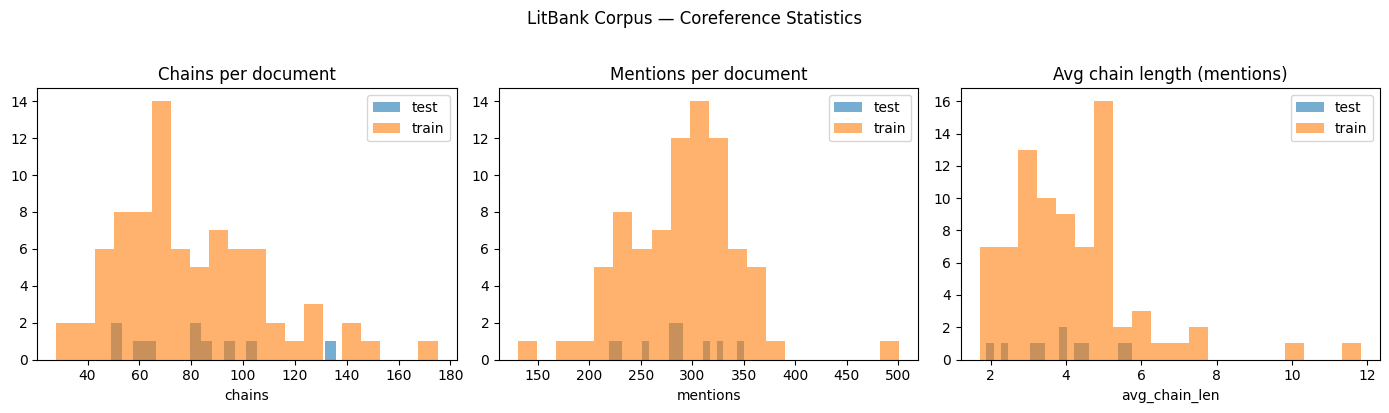

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ["chains", "mentions", "avg_chain_len"],
    ["Chains per document", "Mentions per document", "Avg chain length (mentions)"],
):
    for split, grp in stats_df.groupby("split"):
        ax.hist(grp[col], bins=20, alpha=0.6, label=split)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle("LitBank Corpus — Coreference Statistics", y=1.02)
plt.tight_layout()
plt.show()

## 8. Naive Chunking & Evaluation Metrics

We evaluate three chunking quality metrics defined in `metrics.py`:

| Metric | Definition |
|--------|------------|
| **Cluster Break Rate** | # chains spanning multiple chunks / # total chains |
| **Edge Cut Rate** | # consecutive mention-pairs crossing a chunk boundary / # total edges |
| **Entity Concentration** | (1/K) · Σ_k (most-mentioned entity in chunk k / total mentions in chunk k) |

**Chunking strategy:** sentences are grouped sequentially into fixed-size windows of `chunk_size` sentences (naive baseline).

In [10]:
import sys, os
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from metrics import cluster_break_rate, edge_cut_rate, entity_concentration

In [11]:
def naive_chunk(n_sentences: int, chunk_size: int) -> dict[int, int]:
    """Map each sentence index to a chunk index by fixed-size sequential windows."""
    return {i: i // chunk_size for i in range(n_sentences)}


def compute_metrics(doc: dict, chunk_size: int) -> dict:
    n_sents       = len(doc["sentences"])
    sent_to_chunk = naive_chunk(n_sents, chunk_size)
    total_chunks  = max(sent_to_chunk.values()) + 1
    chains        = doc["coref_chains"]

    return {
        "chunk_size"           : chunk_size,
        "total_chunks"         : total_chunks,
        "cluster_break_rate"   : cluster_break_rate(chains, sent_to_chunk),
        "edge_cut_rate"        : edge_cut_rate(chains, sent_to_chunk),
        "entity_concentration" : entity_concentration(chains, sent_to_chunk, total_chunks),
    }

### Single document — metrics at one chunk size

In [12]:
doc = dataset["train"][0]
result = compute_metrics(doc, chunk_size=5)

print(f"Document : {doc['meta_info']['title']}")
print(f"Sentences: {len(doc['sentences'])}")
print(f"Chunk size (sentences): {result['chunk_size']}")
print(f"Total chunks          : {result['total_chunks']}")
print()
print(f"Cluster Break Rate    : {result['cluster_break_rate']:.3f}")
print(f"Edge Cut Rate         : {result['edge_cut_rate']:.3f}")
print(f"Entity Concentration  : {result['entity_concentration']:.3f}")

Document : Moby Dick; Or, The Whale
Sentences: 94
Chunk size (sentences): 5
Total chunks          : 19

Cluster Break Rate    : 0.046
Edge Cut Rate         : 0.144
Entity Concentration  : 0.318


### Sweep over chunk sizes — how do metrics change?

In [13]:
chunk_sizes = [1, 2, 3, 5, 7, 10, 15, 20]

sweep_results = [compute_metrics(doc, cs) for cs in chunk_sizes]
sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))

 chunk_size  total_chunks  cluster_break_rate  edge_cut_rate  entity_concentration
          1            94            0.068571          0.400              0.510604
          2            47            0.062857          0.296              0.465655
          3            32            0.045714          0.216              0.394735
          5            19            0.045714          0.144              0.317969
          7            14            0.040000          0.120              0.346672
         10            10            0.040000          0.096              0.306722
         15             7            0.028571          0.072              0.294296
         20             5            0.028571          0.064              0.244758


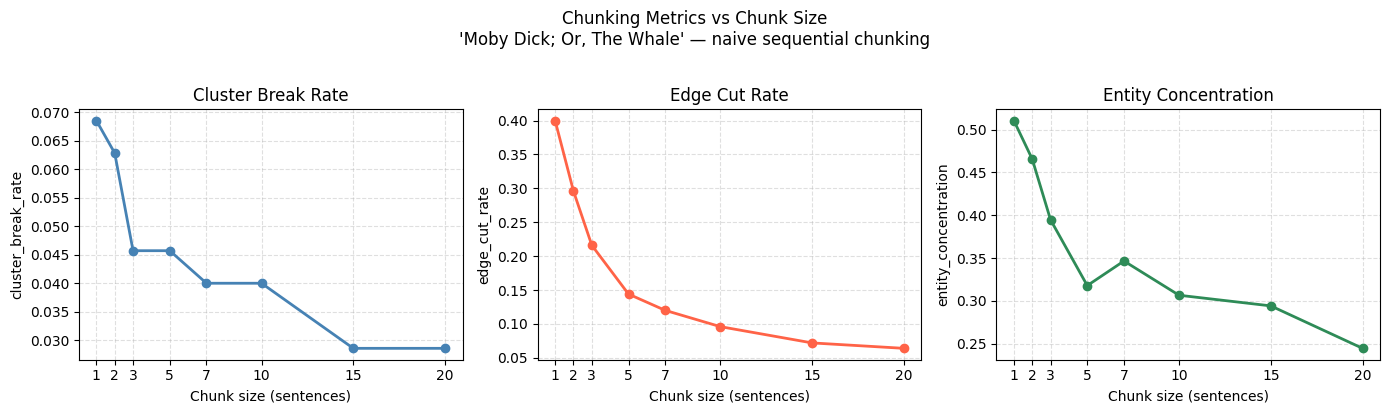

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

metrics_info = [
    ("cluster_break_rate",   "Cluster Break Rate",   "steelblue"),
    ("edge_cut_rate",        "Edge Cut Rate",         "tomato"),
    ("entity_concentration", "Entity Concentration",  "seagreen"),
]

for ax, (col, title, color) in zip(axes, metrics_info):
    ax.plot(sweep_df["chunk_size"], sweep_df[col], marker="o", color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Chunk size (sentences)")
    ax.set_ylabel(col)
    ax.set_xticks(chunk_sizes)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle(
    f"Chunking Metrics vs Chunk Size\n'{doc['meta_info']['title']}' — naive sequential chunking",
    y=1.02
)
plt.tight_layout()
plt.show()

### Corpus-level average metrics (all train documents, chunk_size=5)

Corpus averages (chunk_size=5):
cluster_break_rate      0.179
edge_cut_rate           0.228
entity_concentration    0.437
dtype: float64


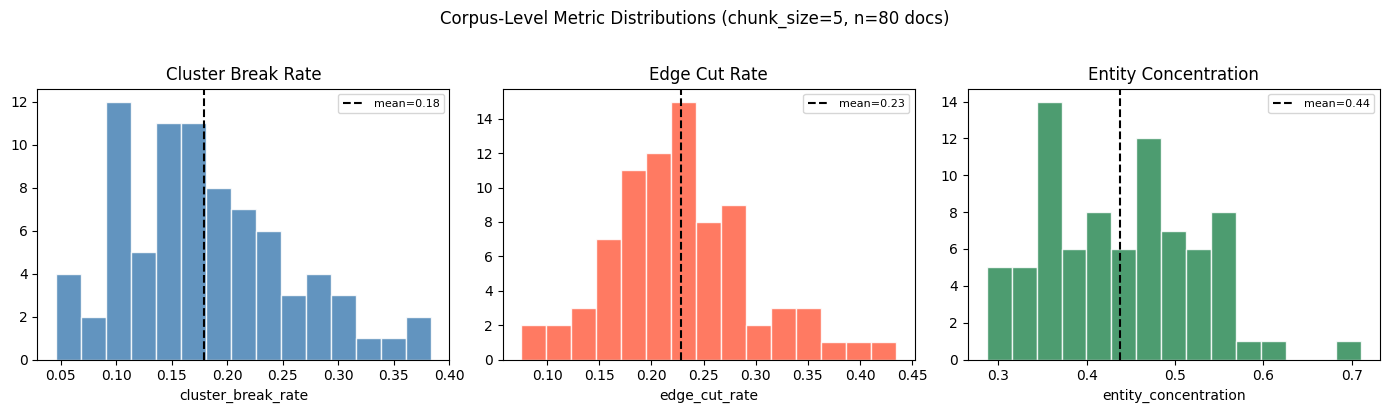

In [15]:
CHUNK_SIZE = 5

corpus_rows = []
for doc in dataset["train"]:
    r = compute_metrics(doc, CHUNK_SIZE)
    r["title"] = doc["meta_info"]["title"][:35]
    corpus_rows.append(r)

corpus_df = pd.DataFrame(corpus_rows)

print(f"Corpus averages (chunk_size={CHUNK_SIZE}):")
print(corpus_df[["cluster_break_rate", "edge_cut_rate", "entity_concentration"]].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, title, color) in zip(axes, metrics_info):
    ax.hist(corpus_df[col], bins=15, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(corpus_df[col].mean(), color="black", linestyle="--", label=f"mean={corpus_df[col].mean():.2f}")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle(f"Corpus-Level Metric Distributions (chunk_size={CHUNK_SIZE}, n={len(corpus_df)} docs)", y=1.02)
plt.tight_layout()
plt.show()